# Libraries and env

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from dotenv import load_dotenv
import os
from pathlib import Path

def load_environment():
    """Load environment variables and return them as a dictionary."""
    load_dotenv(Path("../utils/.env"))  # Loads .env from project root (works if run from notebook too)
    env_vars = {
        "IMAGE_FOLDER": os.getenv("IMAGE_FOLDER"),
        "EXTRACTEDDATASET_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER"),
        "DATASETS_FOLDER": os.getenv("DATASETS_FOLDER"),
        "ElevationDataset": os.getenv("ElevationDataset"),
        "LandCoverDataset": os.getenv("LandCoverDataset"),
        "GeoBoundaries": os.getenv("GeoBoundaries"),
        "EXTRACTEDELEVATION_FOLDER": os.getenv("EXTRACTEDELEVATION_FOLDER"),
        "EXTRACTEDLANDCOVER_FOLDER": os.getenv("EXTRACTEDLANDCOVER_FOLDER"),
        "EXTRACTEDGEOBOUNDARIES_FOLDER": os.getenv("EXTRACTEDGEOBOUNDARIES_FOLDER"),
        "CLEANEDDATASET_FOLDER": os.getenv("CLEANEDDATASET_FOLDER"),
        "CLEANEDELEVATION_FOLDER": os.getenv("CLEANEDELEVATION_FOLDER"),
        "CLEANEDLANDCOVER_FOLDER": os.getenv("CLEANEDLANDCOVER_FOLDER"),
        "PREPROCESSED_DATASET_FOLDER": os.getenv("PREPROCESSED_DATASET_FOLDER"),
        "PREPROCESSED_ELEVATION_FOLDER": os.getenv("PREPROCESSED_ELEVATION_FOLDER"),
        "PREPROCESSED_LANDCOVER_FOLDER": os.getenv("PREPROCESSED_LANDCOVER_FOLDER")
    }
    return env_vars

folders = load_environment()
image_folder = folders["IMAGE_FOLDER"]
extractedData_folder = folders["EXTRACTEDDATASET_FOLDER"]
datasets_folder = folders["DATASETS_FOLDER"]
landCover_folder = folders["LandCoverDataset"]
elevation_folder = folders["ElevationDataset"]
geoboundaries_folder = folders["GeoBoundaries"]
extracted_elevation_folder = folders["EXTRACTEDELEVATION_FOLDER"]
extracted_landcover_folder = folders["EXTRACTEDLANDCOVER_FOLDER"]
extracted_geo_boundaries_folder = folders["EXTRACTEDGEOBOUNDARIES_FOLDER"]
cleaned_dataset_folder = folders["CLEANEDDATASET_FOLDER"]
cleaned_elevation_folder = folders["CLEANEDELEVATION_FOLDER"]
cleaned_landcover_folder = folders["CLEANEDLANDCOVER_FOLDER"]
preprocessed_dataset_folder = folders["PREPROCESSED_DATASET_FOLDER"]
preprocessed_elevation_folder = folders["PREPROCESSED_ELEVATION_FOLDER"]
preprocessed_landcover_folder = folders["PREPROCESSED_LANDCOVER_FOLDER"]


# Read file

In [3]:
#  Path to your extracted elevation raster
elev_path = os.path.join(extracted_elevation_folder, "elevation_dz_tn.tif")
# open rasterio
elev_raster = rasterio.open(elev_path)



from previous analysis we saw that there were outliers, missing values and a left skew distribution

# Preprocessing


## Missing data

In [4]:
#  checking for missing values in elev_raster
elev_data = elev_raster.read(1)
missing_values = (elev_data == elev_raster.nodata).sum()
print(f"Number of missing values in elevation raster: {missing_values}")
print(f"Total number of values in elevation raster: {elev_data.size}")
# calculating percentage of missing values
missing_percentage = (missing_values / elev_data.size) * 100
print(f"percentage of missing values {missing_percentage:.2f}%")



Number of missing values in elevation raster: 8989631
Total number of values in elevation raster: 22121099
percentage of missing values 40.64%


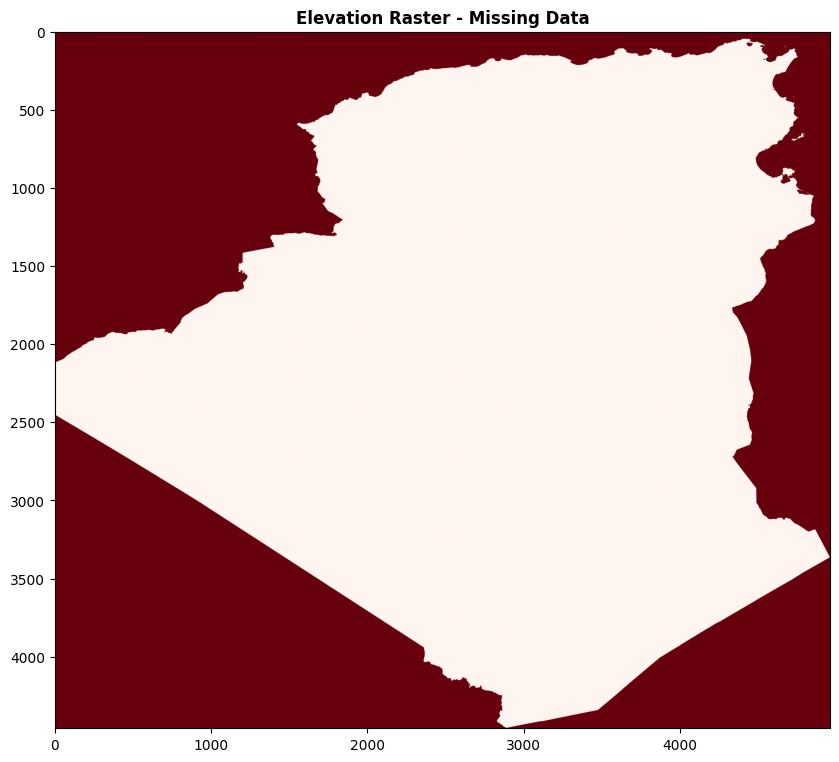

In [5]:
# Visualizing the missing data only
no_data = elev_data == elev_raster.nodata

fig, ax = plt.subplots(figsize=(10, 10))
show(no_data.astype(int), ax=ax, cmap='Reds', title="Elevation Raster - Missing Data")
plt.show()


we have confirmed that its the sea data only, lets remove it

In [7]:
# Open the original raster
with rasterio.open(elev_path) as src:
    data = src.read(1)  # Read the first band
    profile = src.profile  # Copy metadata
    nodata_value = src.nodata  # Get NoData value
    
    print("Original NoData value:", nodata_value)

    # Mask NoData values (set them to np.nan)
    data = np.where(data == nodata_value, np.nan, data)

    # Option 1: Replace NaNs with 0 (if you want to fill them)
    # data = np.nan_to_num(data, nan=0)

    # Option 2: Remove (keep as NaN and set new NoData flag)
    profile.update(
        dtype=rasterio.float32,
        nodata=np.nan
    )

# Save the cleaned raster
with rasterio.open(f"{preprocessed_elevation_folder}/elevation_no_nan.tif", "w", **profile) as dst:
    dst.write(data.astype(rasterio.float32), 1)

print(f"✅ Clean raster saved as elevation_no_nan.tif")


Original NoData value: -32768.0
✅ Clean raster saved as elevation_no_nan.tif


In [8]:
elev_no_nan = rasterio.open(f"{preprocessed_elevation_folder}/elevation_no_nan.tif")


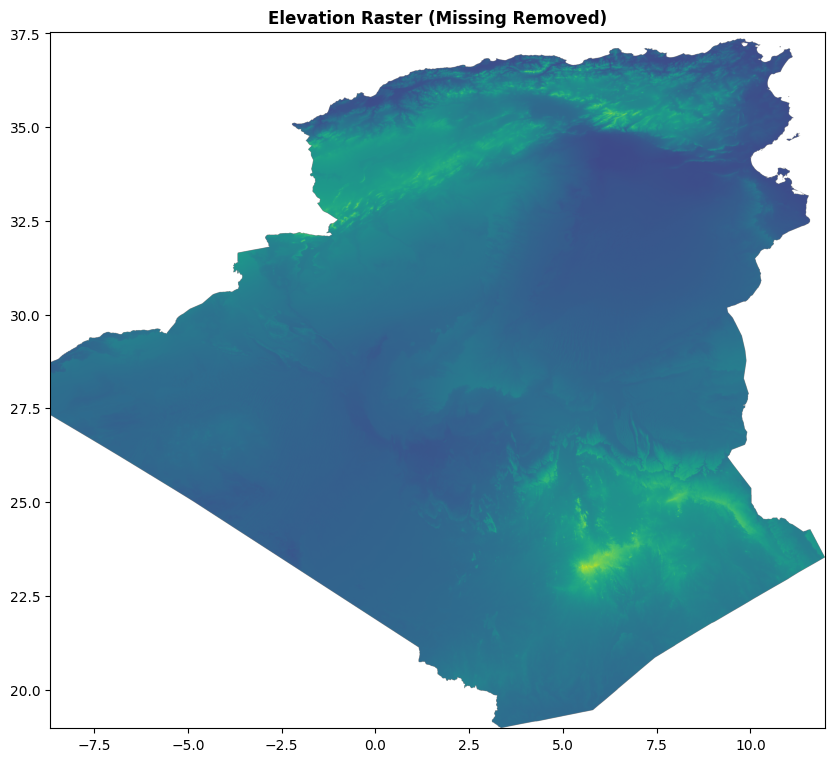

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
show(elev_no_nan, ax=ax, title="Elevation Raster (Missing Removed)")
plt.show()

In [10]:
#  checking
new_elev_data = elev_no_nan.read(1)
missing_values = (new_elev_data == elev_no_nan.nodata).sum()
print(f"Number of missing values in elevation raster: {missing_values}")
print(f"Total number of values in elevation raster: {new_elev_data.size}")
# calculating percentage of missing values
missing_percentage = (missing_values / new_elev_data.size) * 100
print(f"percentage of missing values {missing_percentage:.2f}%")

Number of missing values in elevation raster: 0
Total number of values in elevation raster: 22121099
percentage of missing values 0.00%


## Outliers

we continue from elev_no_nan

In [12]:
# Load the raster without NoData
with rasterio.open(f"{preprocessed_elevation_folder}/elevation_no_nan.tif") as src:
    data = src.read(1).astype(float)
    profile = src.profile

# Optionally check statistics
print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))


Min: -872.0
Max: 2877.0


### ROBUST SCALER for elevation should be left after splitting the datasets

In [ ]:
# median = np.nanmedian(data)
# q1 = np.nanpercentile(data, 25)
# q3 = np.nanpercentile(data, 75)
# iqr = q3 - q1

# normalized = (data - median) / iqr



In [ ]:
# # Update profile for float32 data
# profile.update(dtype=rasterio.float32)

# # Save the normalized raster
# with rasterio.open(f"{preprocessed_elevation_folder}/elev_normalized.tif", "w", **profile) as dst:
#     dst.write(normalized.astype(np.float32), 1)

# print("✅ Normalized raster saved as elev_normalized.tif")


✅ Normalized raster saved as elev_normalized.tif


In [ ]:
# # Load the raster without NoData
# with rasterio.open(f"{preprocessed_elevation_folder}/elev_normalized.tif") as src:
#     data = src.read(1).astype(float)
#     profile = src.profile

# # Optionally check statistics
# print("Min:", np.nanmin(data))
# print("Max:", np.nanmax(data))

Min: -3.4611399173736572
Max: 6.251295566558838


## view Boxplot after normalization

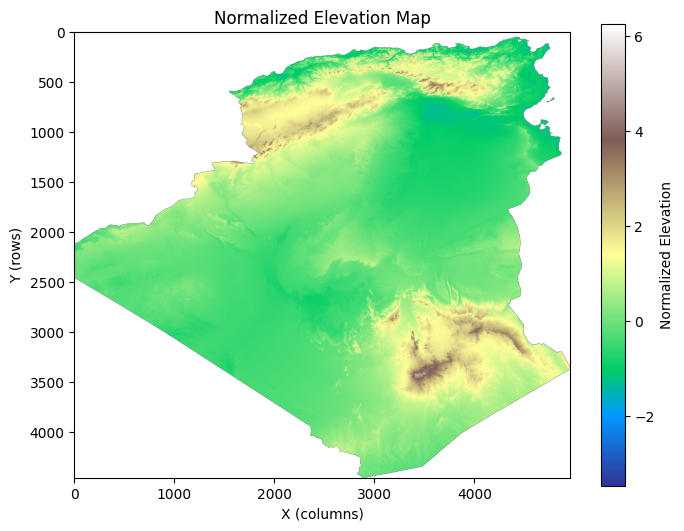

In [ ]:
# import rasterio
# import numpy as np
# import matplotlib.pyplot as plt

# # Load your normalized raster
# with rasterio.open(f"{preprocessed_elevation_folder}/elev_normalized.tif") as src:
#     normalized = src.read(1)
#     profile = src.profile

# # Plot the normalized raster
# plt.figure(figsize=(8, 6))
# plt.imshow(normalized, cmap='terrain')
# plt.colorbar(label='Normalized Elevation')
# plt.title('Normalized Elevation Map')
# plt.xlabel('X (columns)')
# plt.ylabel('Y (rows)')
# plt.show()
